# Постановка задачи


**Цель работы:** изучение основных способов визуализации табличных данных с помощью модулей `seaborn`, `plotly`, `altair`, `bokeh`.

**Краткое описание:** в лабораторной работе представлено 10 заданий на построение графиков разных видов. В каждом задании указано, каким видом графика стоит воспользоваться для визуализации данных. По каждому заданию необходимо построить график дважды: первый раз с помощью модуля `seaborn` (альтернативно можно `matplotlib` со стилями из `seaborn`), второй – с помощью `plotly`, `altair` или `bokeh` на выбор студента. Необязательно каждый раз для второго графика выбирать одну и ту же библиотеку, т.к. не все библиотеки располагают одинаковым набором графиков.

# Данные


По [ссылке](https://drive.google.com/drive/folders/1e0E4vQzaE9LBZgfzz0AzsyAXgtH0eMaP?usp=share_link) расположена таблица с информацией о песнях, исполненных на Евровидении с 2009 по 2023 год. Все задания лабораторной работы необходимо выполнять по этим данным. Данные в полном объеме можно найти [по ссылке](https://www.kaggle.com/datasets/diamondsnake/eurovision-song-contest-data).

##### **Формат данных**

```
year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
2023,Norway,Alessandra,Queen of Kings,English,Pop,Female,1,E Minor,110,36,64,23,10 dB,58,0,10,3,5
2023,Malta,The Busker,Dance (Our Own Party),English,Pop,Male,1,F Minor,103,78,70,82,6 dB,2,0,18,4,
...
```
##### **Описание полей**

- ```year``` – год;
- ```country``` – страна участника;
- ```artist_name``` – исполнитель;
- ```song_name``` – название песни;
- ```language``` – язык, на котором исполняется песня;
- ```style```	– жанр;
- ```gender``` – пол участника;
- ```main_singers``` – количество вокалистов;
- ```key```	– регистр (высота тона);
- ```BPM``` – скорость композиции в целом (количество четвертых нот в минуту);
- ```energy``` – энергичность композиции;
- ```danceability``` – танцевальность (насколько трек подходит для танцев);
- ```happiness``` – жизнерадостность;
- ```loudness``` – громкость;
- ```acousticness``` – акустичность;
- ```instrumentalness``` – инструментальность;
- ```liveness``` – живость;
- ```speechiness``` – насколько много текста;
- ```final_place``` – место в финале.

# Практические задания

>По каждому заданию должен быть сделан вывод. Также нужно обязательно добавлять подпись графика и осей.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
import seaborn as sns

df = pd.read_csv('/content/sample_data/song_data.csv')

## Задание 1

Проведите предобработку числовых значений в датасете:
1. В столбцах `BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` замените отсутствующие значения и прочерки на 0.
2. В столбце `loudness` оставьте только число без единиц измерения.
3. Во всех перечисленных в пунктах 1 и 2 столбцах преобразуйте значения в тип данных `float`.

In [ ]:
# PUT YOUR CODE HERE

numeric_columns = [
    'BPM',
    'energy',
    'danceability',
    'happiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'speechiness'
]

#Замена прочерков на 0
df[numeric_columns] = (
    df[numeric_columns]
    .replace('-', 0, regex=True)
    .fillna(0)
)

#Перевод числовых столбцов в float
df[numeric_columns] = df[numeric_columns].astype(float)

#Удаление единиц измерения из loudness
df['loudness'] = (
    df['loudness']
    .str.replace('dB', '', regex=False)
    .str.strip()
)

#Перевод числовых столбцов в float
columns_to_float = numeric_columns + ['loudness']

df[columns_to_float] = df[columns_to_float].astype(float)

#Проверка результата
display(df[columns_to_float].head())

,BPM,energy,danceability,happiness,acousticness,instrumentalness,liveness,speechiness,loudness
0,110.0,36.0,64.0,23.0,58.0,0.0,10.0,3.0,10.0
1,103.0,78.0,70.0,82.0,2.0,0.0,18.0,4.0,6.0
2,103.0,70.0,56.0,11.0,4.0,2.0,32.0,5.0,10.0
3,160.0,55.0,56.0,40.0,5.0,0.0,8.0,7.0,8.0
4,145.0,63.0,66.0,77.0,31.0,0.0,16.0,5.0,8.0


## Задание 2

Покажите, какие характеристики музыки (`BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`) коррелируют между собой. Для визуализации используйте диаграмму `heatmap`.

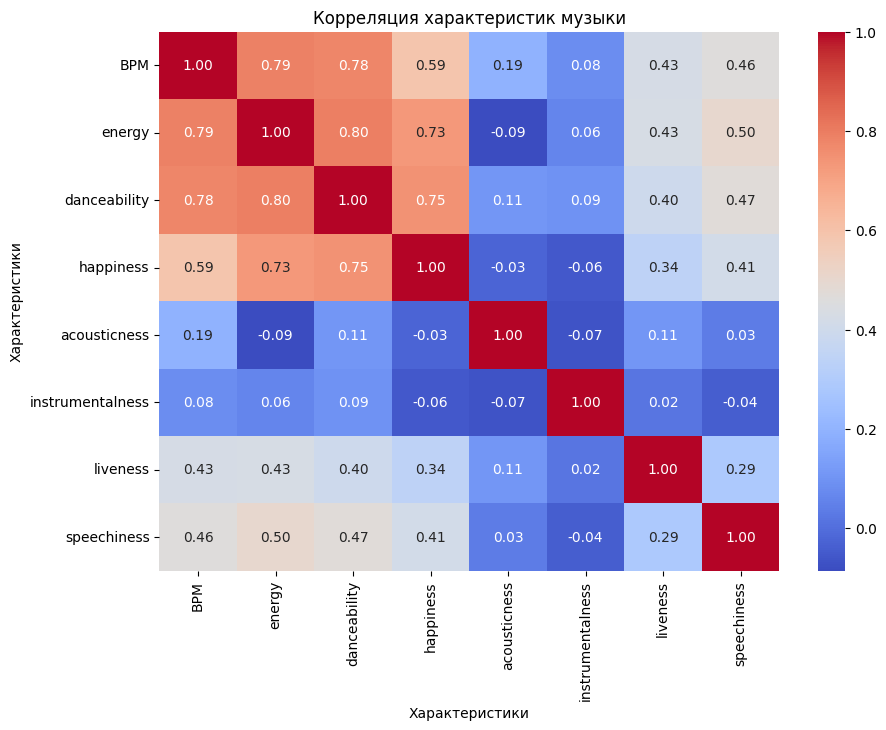

In [ ]:
# PUT YOUR CODE HERE

#Выбор числовых характеристик музыки
music_features = [
    'BPM',
    'energy',
    'danceability',
    'happiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'speechiness'
]

#Расчет корреляции между характеристиками
correlation_matrix = df[music_features].corr()

#Построение тепловой карты корреляции
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

#Подписи графика
plt.title("Корреляция характеристик музыки")
plt.xlabel("Характеристики")
plt.ylabel("Характеристики")

plt.show()

#Построение второй тепловой карты с помощью Plotly
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    labels={
        'x': 'Характеристики',
        'y': 'Характеристики',
        'color': 'Корреляция'
    }
)

#Подпись графика
fig.update_layout(
    title='Корреляция характеристик музыки'
)

fig.show()

## Задание 3

Покажите на диаграмме разброса взаимосвязь между жизнерадостностью (`happiness`) и энергичностью (`energy`) композиции. Добавьте на диаграмму вспомогательные элементы для упрощения интерпретации визуализации:
- отметку средних значений
- выбросы



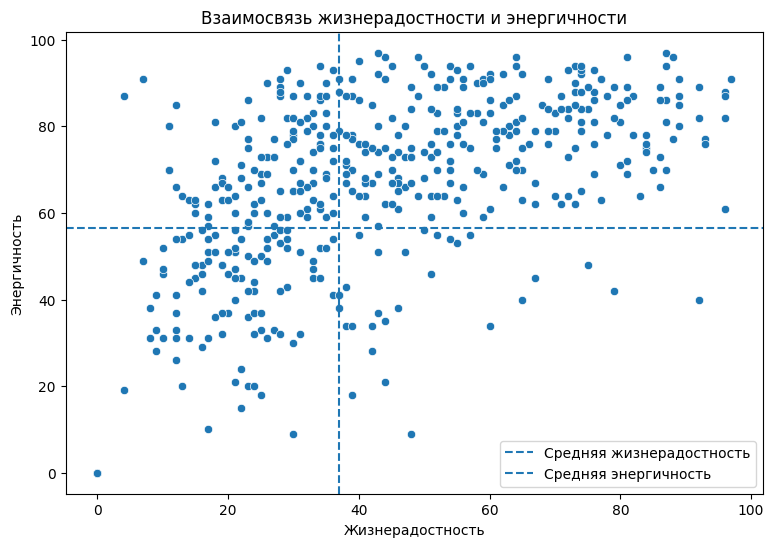

In [ ]:
# PUT YOUR CODE HERE

#Расчет средних значений
mean_happiness = df['happiness'].mean()
mean_energy = df['energy'].mean()

#Расчет границ выбросов для happiness
q1_happiness = df['happiness'].quantile(0.25)
q3_happiness = df['happiness'].quantile(0.75)
iqr_happiness = q3_happiness - q1_happiness

#Расчет границ выбросов для energy
q1_energy = df['energy'].quantile(0.25)
q3_energy = df['energy'].quantile(0.75)
iqr_energy = q3_energy - q1_energy

#Поиск выбросов
outliers = df[
    (df['happiness'] < q1_happiness - 1.5 * iqr_happiness) |
    (df['happiness'] > q3_happiness + 1.5 * iqr_happiness) |
    (df['energy'] < q1_energy - 1.5 * iqr_energy) |
    (df['energy'] > q3_energy + 1.5 * iqr_energy)
]

#Построение диаграммы разброса
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='happiness',
    y='energy'
)

#Выделение выбросов
sns.scatterplot(
    data=outliers,
    x='happiness',
    y='energy',
    color='red',
    label='Выбросы'
)

#Отметка средних значений
plt.axvline(mean_happiness, linestyle='--', label='Средняя жизнерадостность')
plt.axhline(mean_energy, linestyle='--', label='Средняя энергичность')

#Подписи графика
plt.title("Взаимосвязь жизнерадостности и энергичности")
plt.xlabel("Жизнерадостность")
plt.ylabel("Энергичность")
plt.legend()

plt.show()


#Подготовка данных для Plotly
plot_data = df[['happiness', 'energy']].copy()
plot_data['Тип точки'] = 'Обычные значения'

#Обозначение выбросов
plot_data.loc[outliers.index, 'Тип точки'] = 'Выбросы'

#Построение диаграммы разброса
fig = px.scatter(
    plot_data,
    x='happiness',
    y='energy',
    color='Тип точки',
    labels={
        'happiness': 'Жизнерадостность',
        'energy': 'Энергичность'
    },
    title='Взаимосвязь жизнерадостности и энергичности'
)

#Отметка среднего значения жизнерадостности
fig.add_vline(
    x=mean_happiness,
    line_dash='dash'
)

#Отметка среднего значения энергичности
fig.add_hline(
    y=mean_energy,
    line_dash='dash'
)

fig.show()

## Задание 4

Покажите на горизонтальной столбчатой диаграмме распределение количества треков по жанрам. Отсортируйте диаграмму по убыванию количества композиций в жанре. Выделите контрастным цветом жанр, в котором больше всего песен.

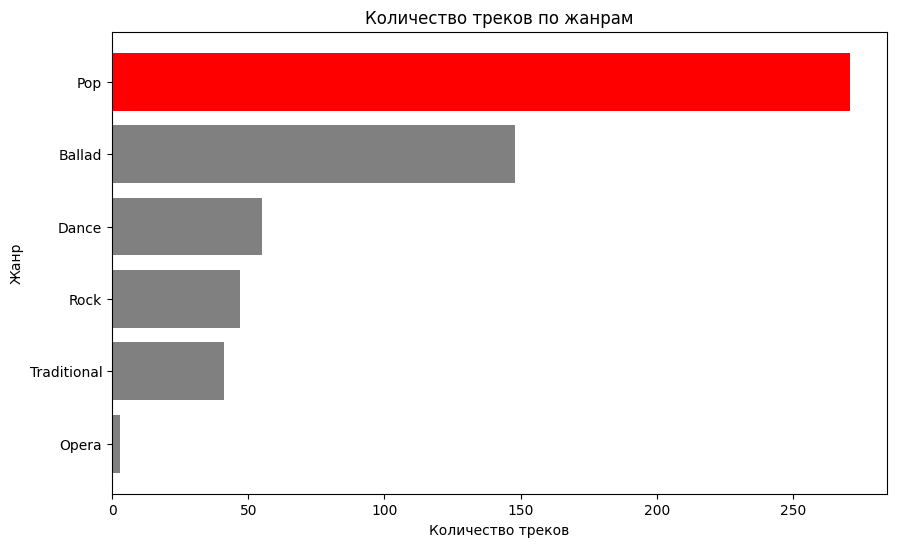

In [ ]:
# PUT YOUR CODE HERE

#Подсчет количества треков по жанрам
genre_counts = (
    df['style']
    .value_counts()
    .sort_values(ascending=False)
)

#Цвета столбцов: самый частый жанр выделяем
colors = [
    'red' if genre == genre_counts.index[0] else 'gray'
    for genre in genre_counts.index
]

#Построение горизонтальной столбчатой диаграммы
plt.figure(figsize=(10, 6))

plt.barh(
    genre_counts.index,
    genre_counts.values,
    color=colors
)

#Расположение самого частого жанра сверху
plt.gca().invert_yaxis()

#Подписи графика
plt.title("Количество треков по жанрам")
plt.xlabel("Количество треков")
plt.ylabel("Жанр")

plt.show()



#Подготовка данных для Plotly
genre_plot = genre_counts.reset_index()
genre_plot.columns = ['style', 'count']

#Добавление признака для выделения самого популярного жанра
genre_plot['highlight'] = genre_plot['style'].apply(
    lambda x: 'Самый популярный жанр'
    if x == genre_counts.index[0]
    else 'Другие жанры'
)

#Построение горизонтальной столбчатой диаграммы
fig = px.bar(
    genre_plot,
    x='count',
    y='style',
    color='highlight',
    orientation='h',
    labels={
        'count': 'Количество треков',
        'style': 'Жанр',
        'highlight': 'Категория'
    },
    title='Количество треков по жанрам'
)

#Сортировка жанров по убыванию количества
fig.update_layout(
    yaxis={
        'categoryorder': 'total ascending'
    }
)

fig.show()

## Задание 5

Покажите на круговой диаграмме страны, участники из которых побеждали чаще других, и в каких годах они выигрывали. Диаграмма должна быть одна.

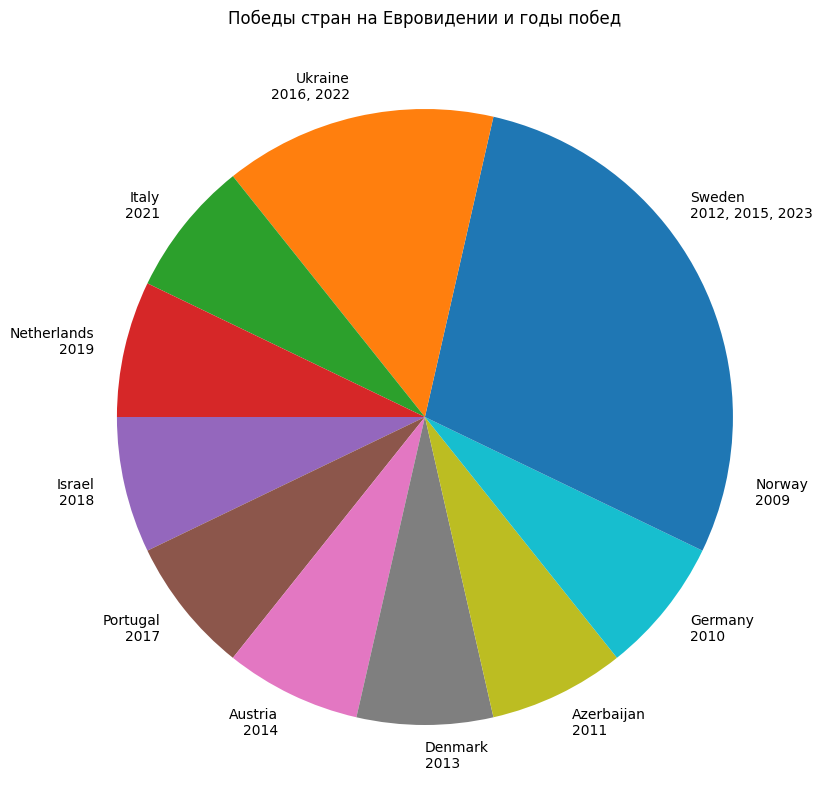

In [ ]:
# PUT YOUR CODE HERE

#Выбор победителей Евровидения
winners = df[df['final_place'] == 1].copy()

#Подсчет количества побед каждой страны
country_wins = winners['country'].value_counts()

#Подготовка подписей с годами побед
labels = []

for country in country_wins.index:
    years = (
        winners.loc[winners['country'] == country, 'year']
        .sort_values()
        .astype(int)
        .astype(str)
        .tolist()
    )

    labels.append(
        f"{country}\n{', '.join(years)}"
    )

#Построение одной круговой диаграммы
plt.figure(figsize=(10, 10))

plt.pie(
    country_wins.values,
    labels=labels,
)

#Подпись диаграммы
plt.title("Победы стран на Евровидении и годы побед")

plt.show()



#Подготовка данных победителей
winners_plot = df[df['final_place'] == 1].copy()

#Преобразование года в строку для отображения
winners_plot['year'] = winners_plot['year'].astype(str)

#Построение круговой диаграммы через Plotly
fig = px.sunburst(
    winners_plot,
    path=['country', 'year'],
    values=None,
    title='Победы стран на Евровидении и годы побед'
)

fig.show()

## Задание 6

На вертикальной столбчатой диаграмме с группировкой покажите количество мужчин и женщин среди участников в каждом году, представленном в датасете.

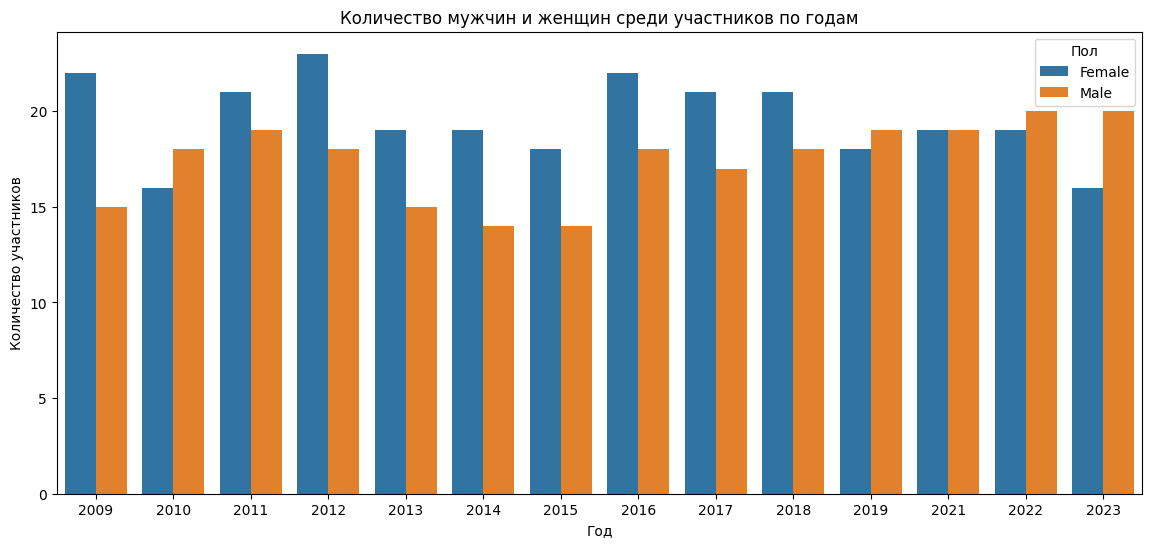

In [ ]:
# PUT YOUR CODE HERE

#Выбор участников мужского и женского пола
gender_data = df[df['gender'].isin(['Male', 'Female'])]

#Подсчет количества мужчин и женщин по годам
gender_counts = (
    gender_data
    .groupby(['year', 'gender'])
    .size()
    .reset_index(name='Количество')
)

#Построение вертикальной столбчатой диаграммы с группировкой
plt.figure(figsize=(14, 6))

sns.barplot(
    data=gender_counts,
    x='year',
    y='Количество',
    hue='gender'
)

#Подписи графика
plt.title("Количество мужчин и женщин среди участников по годам")
plt.xlabel("Год")
plt.ylabel("Количество участников")
plt.legend(title="Пол")

plt.show()

#Построение второй диаграммы через Plotly
fig = px.bar(
    gender_counts,
    x='year',
    y='Количество',
    color='gender',
    barmode='group',
    labels={
        'year': 'Год',
        'Количество': 'Количество участников',
        'gender': 'Пол'
    },
    title='Количество мужчин и женщин среди участников по годам'
)

fig.show()

## Задание 7

Постройте график плотности распределения данных в столбце `danceability` (танцевальность), сгруппированных по категориям жанрам.

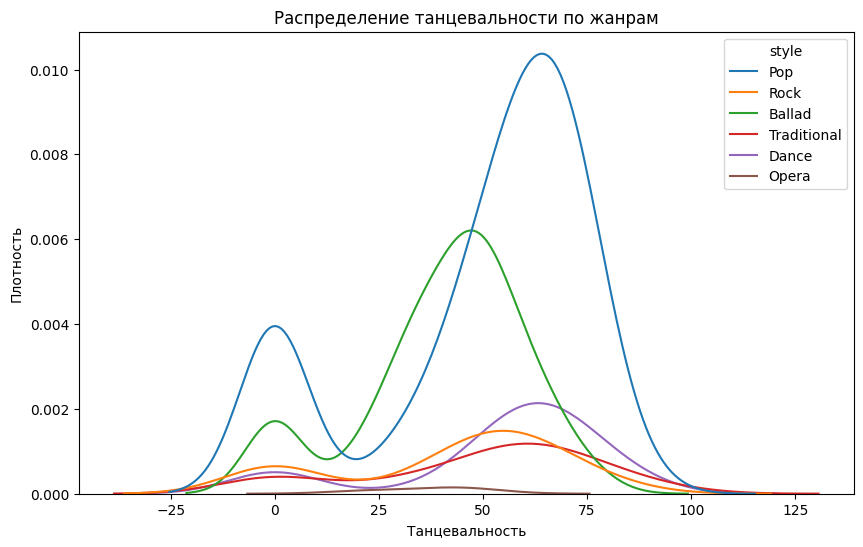

alt.Chart(...)

In [ ]:
# PUT YOUR CODE HERE

#Построение графика плотности танцевальности по жанрам
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='danceability',
    hue='style',
    fill=False
)

#Подписи графика
plt.title("Распределение танцевальности по жанрам")
plt.xlabel("Танцевальность")
plt.ylabel("Плотность")

plt.show()


#Построение второго графика плотности через Altair
density_chart = (
    alt.Chart(df.dropna(subset=['danceability', 'style']))
    .transform_density(
        'danceability',
        groupby=['style'],
        as_=['danceability', 'density'],
        extent=[0, 100]
    )
    .mark_line()
    .encode(
        x=alt.X(
            'danceability:Q',
            title='Танцевальность'
        ),
        y=alt.Y(
            'density:Q',
            title='Плотность'
        ),
        color=alt.Color(
            'style:N',
            title='Жанр'
        )
    )
    .properties(
        width=700,
        height=400,
        title='Распределение танцевальности по жанрам'
    )
)

density_chart

## Задание 8

Покажите на ящиковой диаграмме взяимосвязь позиции в финальном рейтинге со страной. Итоги каких стран похожи между собой? Отсортируйте или сгруппируйте ящики так, чтобы упростить интерпретацию графика.

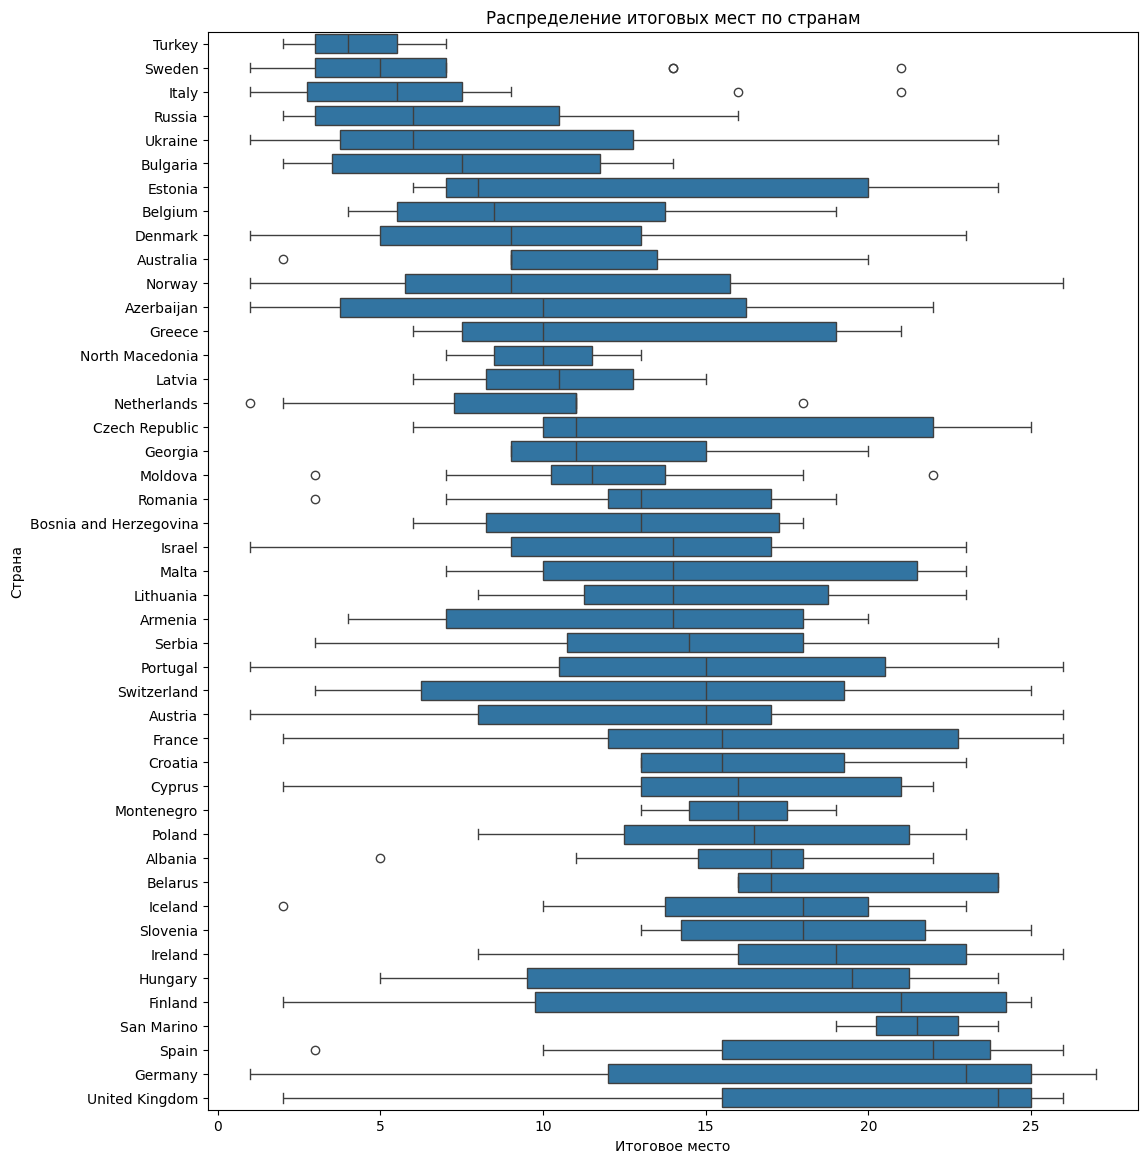

In [ ]:
# PUT YOUR CODE HERE

#Удаление строк без итогового места
final_data = df.dropna(subset=['final_place'])

#Сортировка стран по медианному итоговому месту
country_order = (
    final_data
    .groupby('country')['final_place']
    .median()
    .sort_values()
    .index
)

#Построение ящиковой диаграммы
plt.figure(figsize=(12, 14))

sns.boxplot(
    data=final_data,
    x='final_place',
    y='country',
    order=country_order
)

#Подписи графика
plt.title("Распределение итоговых мест по странам")
plt.xlabel("Итоговое место")
plt.ylabel("Страна")

plt.show()


#Построение второй ящиковой диаграммы через Plotly
fig = px.box(
    final_data,
    x='final_place',
    y='country',
    category_orders={
        'country': list(country_order)
    },
    labels={
        'final_place': 'Итоговое место',
        'country': 'Страна'
    },
    title='Распределение итоговых мест по странам'
)

fig.show()

## Задание 9

Покажите на карте количество раз, когда каждая страна датасета проходила в финал.

In [ ]:
# PUT YOUR CODE HERE

#Выбор участников, прошедших в финал
finalists = df.dropna(subset=['final_place'])

#Подсчет количества выходов в финал для каждой страны
final_counts = (
    finalists['country']
    .value_counts()
    .reset_index()
)

final_counts.columns = ['country', 'final_count']

#Построение карты количества выходов стран в финал
fig = px.choropleth(
    final_counts,
    locations='country',
    locationmode='country names',
    color='final_count',
    hover_name='country',
    labels={
        'final_count': 'Количество выходов в финал',
        'country': 'Страна'
    }
)

#Подпись карты
fig.update_layout(
    title='Количество выходов стран в финал Евровидения'
)

fig.show()

## Задание 10

Покажите на диаграмме вида `treemap`, сколько раз каждая страна входила в топ-3 победителей.

*В `seaborn` нет такого типа графика, с помощью этого модуля строить график не нужно.*

In [ ]:
# PUT YOUR CODE HERE

#Выбор стран, которые занимали места с 1 по 3
top3 = df[df['final_place'].isin([1, 2, 3])]

#Подсчет количества попаданий каждой страны в топ-3
top3_counts = (
    top3['country']
    .value_counts()
    .reset_index()
)

top3_counts.columns = ['country', 'top3_count']

#Построение treemap
fig = px.treemap(
    top3_counts,
    path=['country', 'top3_count'],
    values='top3_count',
    color='top3_count',
    labels={
        'country': 'Страна',
        'top3_count': 'Количество попаданий в топ-3'
    }
)

#Подпись диаграммы
fig.update_layout(
    title='Количество попаданий стран в топ-3 Евровидения'
)

fig.show()

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения 10 заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой построение визуализации по данным из лабораторной работы, по сложности аналогичной тем, что требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. Покажите на ящиковой диаграмме распределение танцевальности для каждого жанра. Выполните с помощью `seaborn`.
2. На круговой диаграмме покажите исполнителей, которые участвовали больше одного раза и какие места они занимали. Выполните с помощью `plotly`.
3. Покажите на диаграмме вида `treemap`, сколько раз каждая страна проходила в финал. Выполните с помощью `plotly`.

# Дополнительные материалы

1. seaborn: statistical data visualization [Электронный ресурс]. URL: https://seaborn.pydata.org/ (дата обращения: 01.04.2024).
2. Plotly Open Source Graphing Libraries [Электронный ресурс]. URL: https://plotly.com/graphing-libraries/ (дата обращения: 01.04.2024).
3. Vega-Altair: Declarative Visualization in Python [Электронный ресурс]. URL: https://altair-viz.github.io/index.html (дата обращения: 01.04.2024).